# TCP Force Analysis
Plot `tcp_force` from `ur_rtde_real_time.py` NPZ logs.

`tcp_force` shape: `(T, 12)` — columns 0-5 are left arm `[Fx, Fy, Fz, Tx, Ty, Tz]`, columns 6-11 are right arm, in the UR base frame (N / Nm).
Data is at 500 Hz (src_dt = 0.002 s). Raw values include a static gravity-bias from the arm+gripper weight — subtract an estimated baseline if needed.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

FORCE_LABELS = ['Fx', 'Fy', 'Fz']
TORQUE_LABELS = ['Tx', 'Ty', 'Tz']


def _src_dt(d):
    return float(d['src_dt']) if 'src_dt' in d.files else 1.0 / 500.0


def _time_axis(d):
    """Wall-clock time in seconds for each control tick."""
    return d['steps'] * _src_dt(d)


def _estimate_baseline(tcp_force, n_steps=50):
    """Mean of the first n_steps as an approximation of the static gravity bias."""
    return tcp_force[:n_steps].mean(axis=0)


def analyze_tcp_force(npz_path, ds=1, subtract_baseline=False, baseline_steps=50):
    """
    Plot TCP force and torque for both arms over the full rollout.

    Parameters
    ----------
    npz_path : str or Path
    ds : int
        Downsample factor (1 = all 500 Hz data).
    subtract_baseline : bool
        If True, subtract the mean of the first `baseline_steps` ticks
        as an estimate of the static gravity + gripper bias.
    baseline_steps : int
        Number of initial ticks used to estimate the baseline.
    """
    npz_path = Path(npz_path)
    d = np.load(npz_path)
    title = npz_path.stem
    rate_hz = 1.0 / _src_dt(d)

    if 'tcp_force' not in d.files:
        print(f'No tcp_force in {npz_path.name}')
        return

    f = d['tcp_force']  # (T, 12)
    t = _time_axis(d)   # (T,)  seconds

    dual_arm = bool(d['dual_arm']) if 'dual_arm' in d.files else (f.shape[1] == 12)
    arms = [('Left', slice(0, 6)), ('Right', slice(6, 12))] if dual_arm else [('Left', slice(0, 6))]

    if subtract_baseline:
        baseline = _estimate_baseline(f, baseline_steps)
        f = f - baseline
        print(f'Baseline (first {baseline_steps} ticks):')
        for arm_name, sl in arms:
            b = baseline[sl]
            print(f'  {arm_name}: F=[{b[0]:.2f}, {b[1]:.2f}, {b[2]:.2f}] N  '
                  f'T=[{b[3]:.3f}, {b[4]:.3f}, {b[5]:.3f}] Nm')

    n = len(arms)
    src = f"src_dt={_src_dt(d)*1000:.1f} ms ({rate_hz:.0f} Hz)"
    label_suffix = ' (baseline-subtracted)' if subtract_baseline else ' (raw)'

    # --- Force magnitude ---
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 4), sharey=False)
    if n == 1:
        axes = [axes]
    for ax, (arm_name, sl) in zip(axes, arms):
        fmag = np.linalg.norm(f[::ds, sl.start:sl.start + 3], axis=1)
        ax.plot(t[::ds], fmag, color='tab:blue', linewidth=0.8)
        ax.set_xlabel('time (s)')
        ax.set_ylabel('||F|| (N)')
        ax.set_title(f'{arm_name} arm — force magnitude{label_suffix}')
        ax.grid(True, alpha=0.3)
    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.show()

    # --- Force components per arm ---
    fig, axes = plt.subplots(n, 3, figsize=(14, 4 * n), sharex=True)
    if n == 1:
        axes = axes[np.newaxis, :]
    colors = ['tab:red', 'tab:green', 'tab:blue']
    for row, (arm_name, sl) in enumerate(arms):
        for col, (label, color) in enumerate(zip(FORCE_LABELS, colors)):
            ax = axes[row, col]
            ax.plot(t[::ds], f[::ds, sl.start + col], color=color, linewidth=0.8)
            ax.axhline(0, color='k', linewidth=0.4, linestyle='--')
            ax.set_title(f'{arm_name} — {label}{label_suffix}', fontsize=10)
            ax.set_ylabel('N')
            ax.grid(True, alpha=0.3)
        axes[row, 1].set_xlabel('time (s)')
    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.show()

    # --- Torque components per arm ---
    fig, axes = plt.subplots(n, 3, figsize=(14, 4 * n), sharex=True)
    if n == 1:
        axes = axes[np.newaxis, :]
    for row, (arm_name, sl) in enumerate(arms):
        for col, (label, color) in enumerate(zip(TORQUE_LABELS, colors)):
            ax = axes[row, col]
            ax.plot(t[::ds], f[::ds, sl.start + 3 + col], color=color, linewidth=0.8)
            ax.axhline(0, color='k', linewidth=0.4, linestyle='--')
            ax.set_title(f'{arm_name} — {label}{label_suffix}', fontsize=10)
            ax.set_ylabel('Nm')
            ax.grid(True, alpha=0.3)
        axes[row, 1].set_xlabel('time (s)')
    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.show()

    print(f'{title}  |  {len(t)} steps  |  {src}')
    print('Force stats (N):')
    for arm_name, sl in arms:
        fmag = np.linalg.norm(f[:, sl.start:sl.start + 3], axis=1)
        print(f'  {arm_name}: ||F|| mean={fmag.mean():.2f}  max={fmag.max():.2f}')
        for i, label in enumerate(FORCE_LABELS):
            v = f[:, sl.start + i]
            print(f'    {label}: mean={v.mean():.2f}  std={v.std():.2f}  min={v.min():.2f}  max={v.max():.2f}')

In [ ]:
def _is_sim_rollout(d):
    return 'ee_force_mag' in d.files and 'tcp_force' not in d.files


def _extract_force_mag(d, arm_idx, env_idx=0, ds=1, subtract_baseline=False, baseline_steps=200):
    """Return (t, fmag) for either a real (tcp_force) or sim (ee_force_mag) npz."""
    t = _time_axis(d)[::ds]
    if _is_sim_rollout(d):
        # ee_force_mag: (T, N, S) — S sensors, one per EE arm
        mag = d['ee_force_mag'][:, env_idx, arm_idx]  # (T,)
        if subtract_baseline:
            mag = mag - mag[:baseline_steps].mean()
        return t, mag[::ds]
    else:
        f = d['tcp_force']  # (T, 12)
        if subtract_baseline:
            f = f - _estimate_baseline(f, baseline_steps)
        sl = slice(arm_idx * 6, arm_idx * 6 + 3)
        return t, np.linalg.norm(f[::ds, sl], axis=1)


def compare_tcp_force(npz_paths, labels=None, ds=2, subtract_baseline=False, baseline_steps=50):
    """
    Overlay force magnitude for multiple rollouts on the same axes.
    Accepts both real-robot npz files (tcp_force) and sim rollout npz files (ee_force_mag).

    Parameters
    ----------
    npz_paths : list of str or Path
    labels : list of str, optional — defaults to filename stems
    ds : int
        Downsample factor.
    subtract_baseline : bool
        Subtract per-rollout static bias (first baseline_steps ticks).
    """
    npz_paths = [Path(p) for p in npz_paths]
    if labels is None:
        labels = [p.stem for p in npz_paths]

    d0 = np.load(npz_paths[0])
    dual_arm = bool(d0['dual_arm']) if 'dual_arm' in d0.files else False
    arms = [('Left', 0), ('Right', 1)] if dual_arm else [('Left', 0)]

    n_arms = len(arms)
    fig, axes = plt.subplots(1, n_arms, figsize=(7 * n_arms, 4), sharey=False)
    if n_arms == 1:
        axes = [axes]

    for npz_path, label in zip(npz_paths, labels):
        d = np.load(npz_path)
        sim = _is_sim_rollout(d)
        if not sim and 'tcp_force' not in d.files:
            print(f'  skip {npz_path.name}: no tcp_force or ee_force_mag')
            continue
        ls = '--' if sim else '-'
        for ax, (arm_name, arm_idx) in zip(axes, arms):
            try:
                t, fmag = _extract_force_mag(d, arm_idx, ds=ds,
                                             subtract_baseline=subtract_baseline,
                                             baseline_steps=baseline_steps)
                ax.plot(t, fmag, linewidth=0.9, linestyle=ls,
                        label=f"{label} ({'sim' if sim else 'real'})")
            except IndexError:
                print(f'  skip {npz_path.name} {arm_name}: sensor index out of range')

    suffix = ' (baseline-subtracted)' if subtract_baseline else ' (raw)'
    for ax, (arm_name, _) in zip(axes, arms):
        ax.set_title(f'{arm_name} arm — ||F||{suffix}')
        ax.set_xlabel('time (s)')
        ax.set_ylabel('||F|| (N)')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, loc='best')
    plt.tight_layout()
    plt.show()

## Single rollout

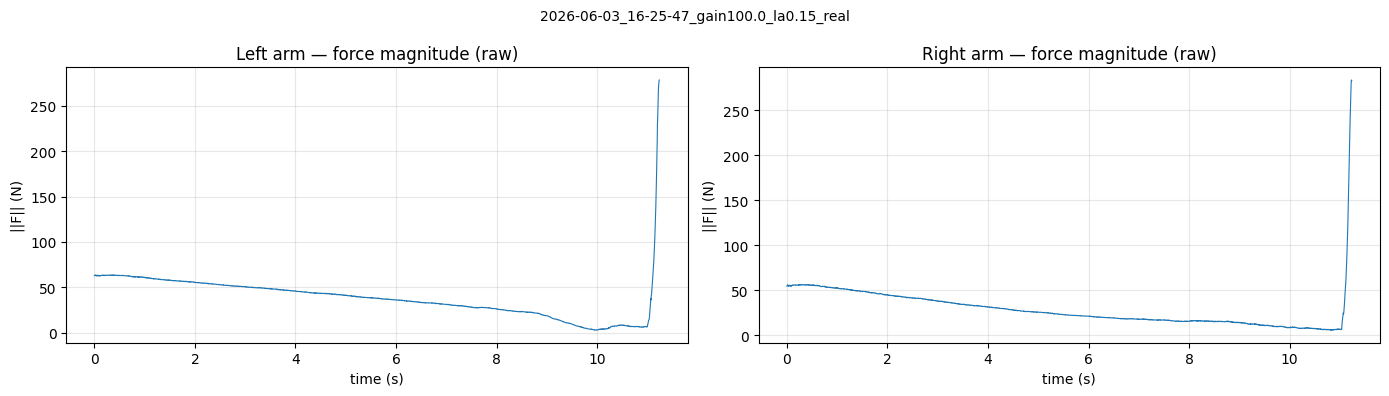

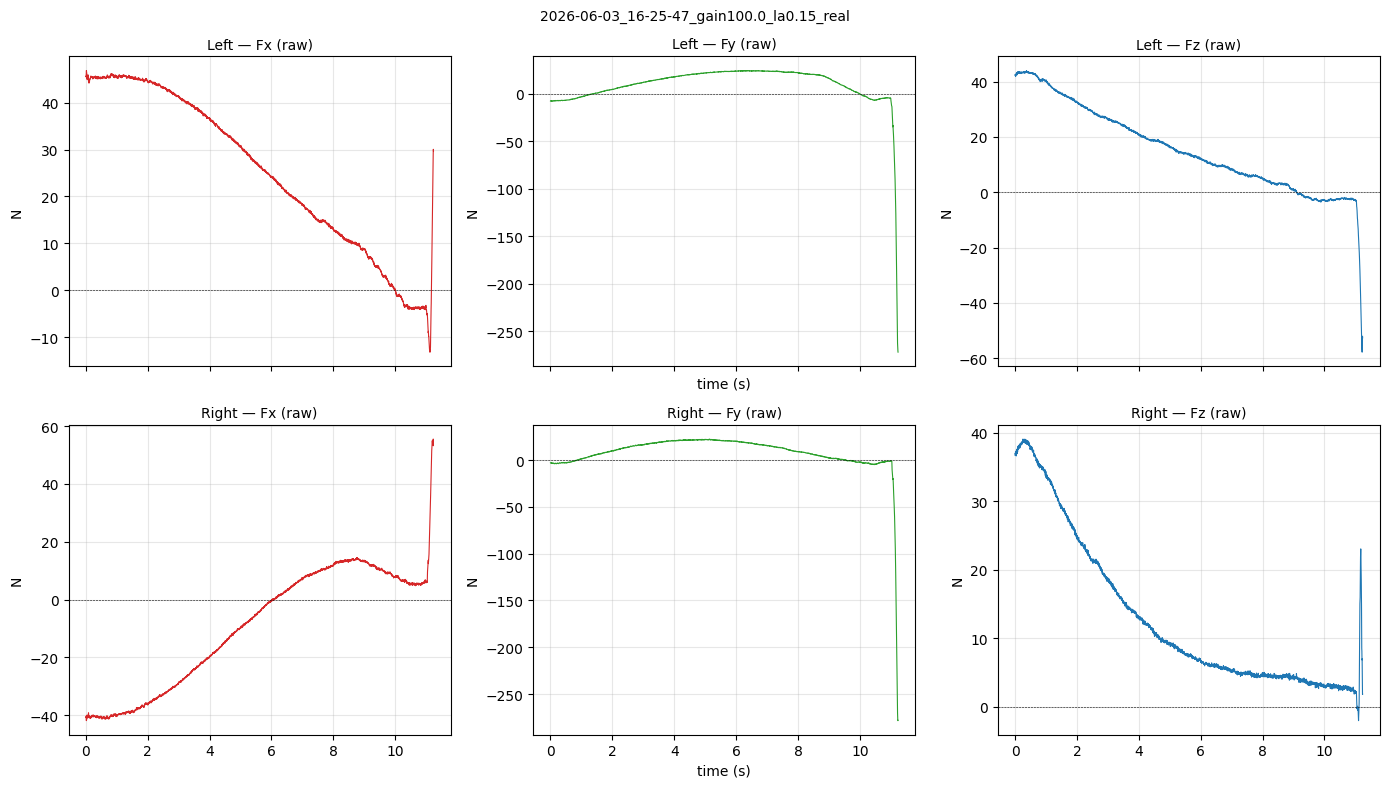

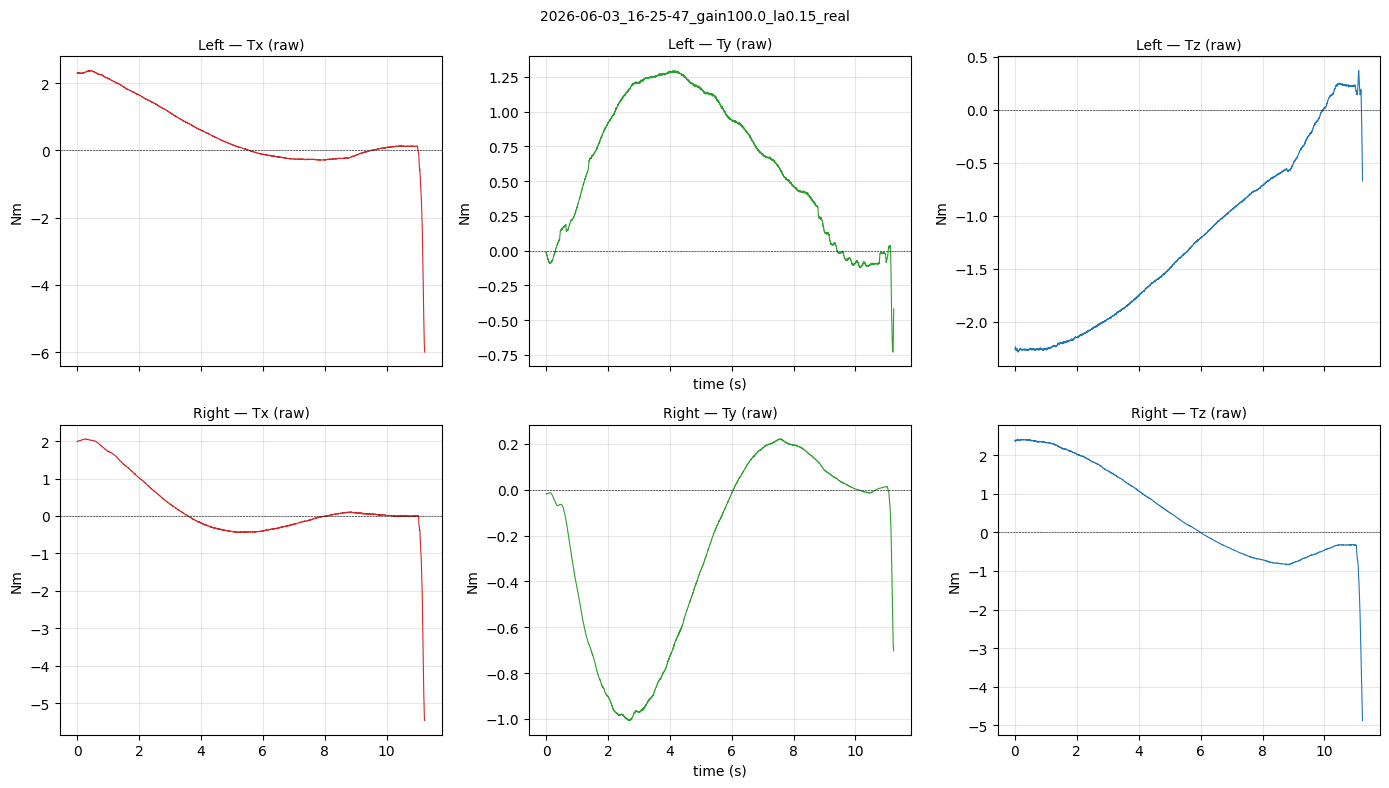

2026-06-03_16-25-47_gain100.0_la0.15_real  |  5619 steps  |  src_dt=2.0 ms (500 Hz)
Force stats (N):
  Left: ||F|| mean=38.05  max=278.55
    Fx: mean=25.07  std=16.81  min=-13.16  max=46.82
    Fy: mean=9.56  std=22.84  min=-271.91  max=24.34
    Fz: mean=15.46  std=15.76  min=-57.86  max=44.03
  Right: ||F|| mean=28.92  max=284.07
    Fx: mean=-9.41  std=20.60  min=-42.28  max=55.79
    Fy: mean=8.05  std=21.96  min=-278.53  max=22.53
    Fz: mean=12.93  std=11.10  min=-2.30  max=39.25


In [5]:
NPZ = r'../logs/rsl_rl/boxlift/2026-06-02_22-26-01/ur_rtde_logs/2026-06-03_16-25-47_gain100.0_la0.15_real.npz'

analyze_tcp_force(NPZ, ds=2, subtract_baseline=False)

## Baseline-subtracted (removes static gravity + gripper bias)

Baseline (first 50 ticks):
  Left: F=[45.35, -7.72, 42.84] N  T=[2.303, -0.049, -2.266] Nm
  Right: F=[-40.59, -3.18, 37.19] N  T=[2.002, -0.016, 2.383] Nm


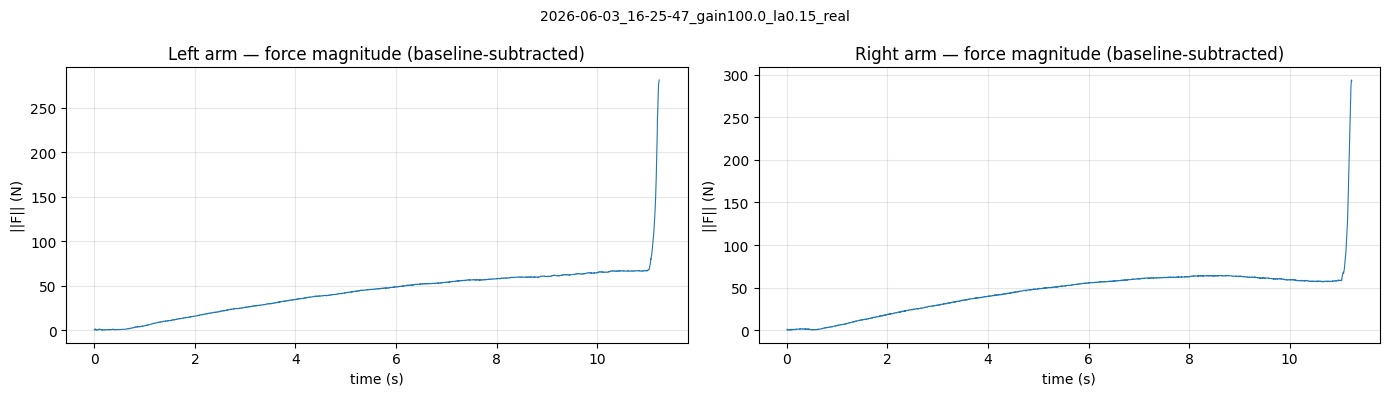

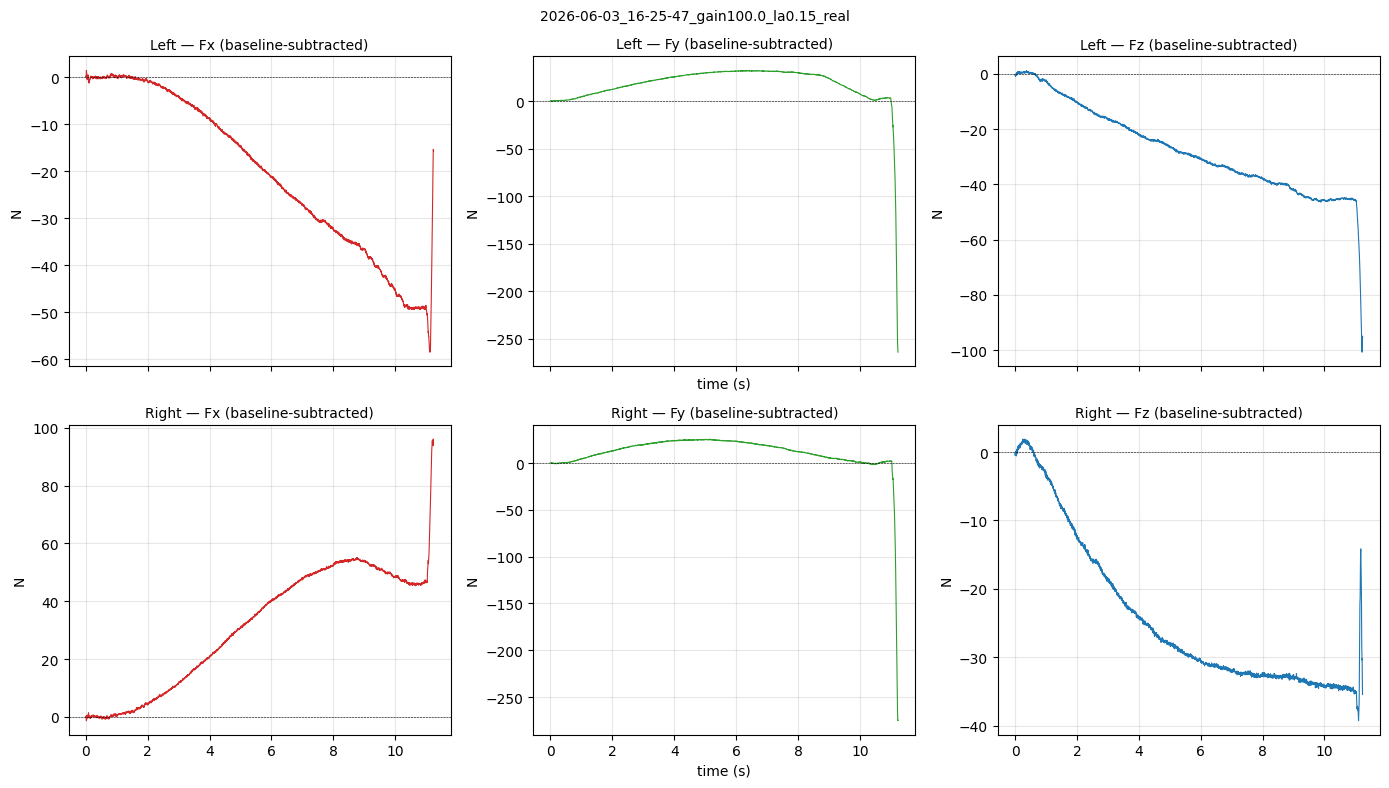

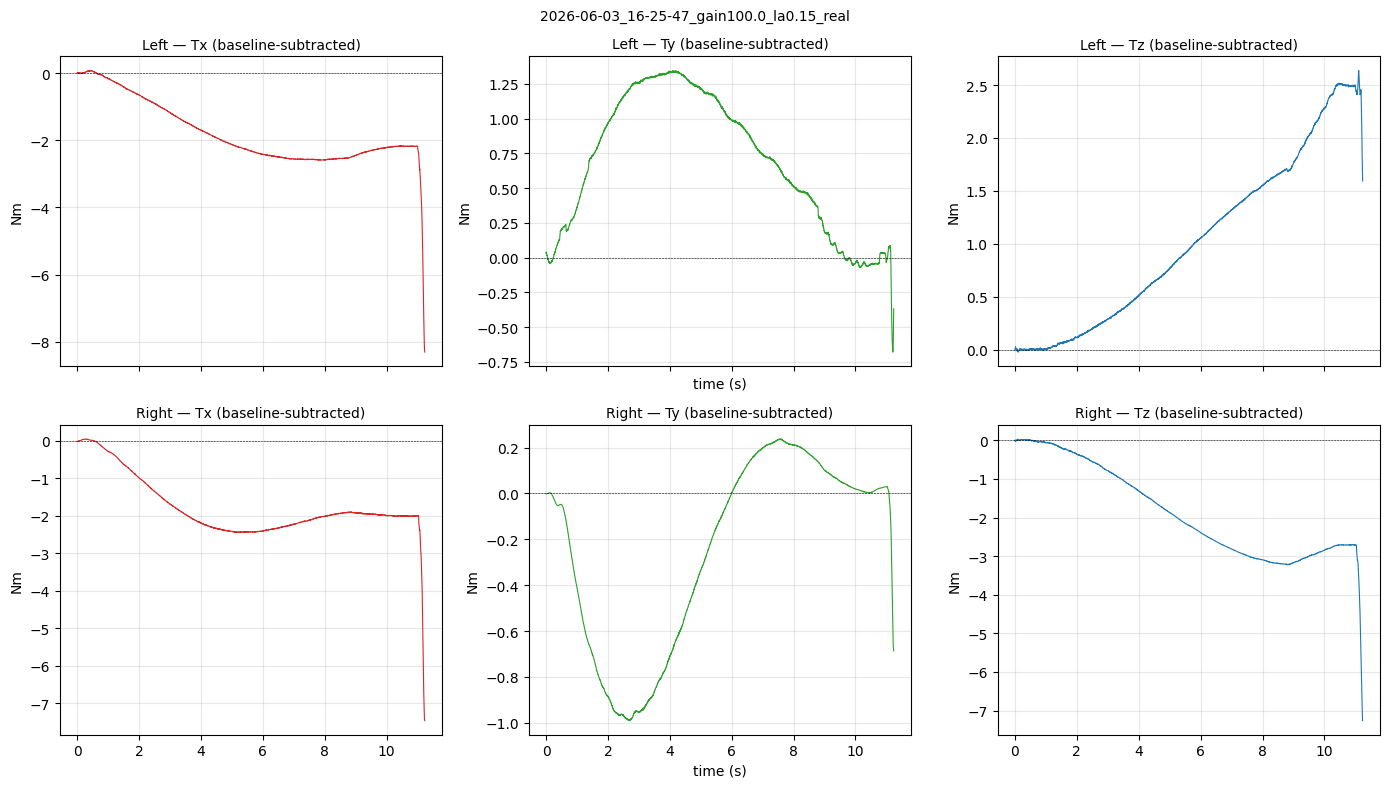

2026-06-03_16-25-47_gain100.0_la0.15_real  |  5619 steps  |  src_dt=2.0 ms (500 Hz)
Force stats (N):
  Left: ||F|| mean=42.44  max=281.36
    Fx: mean=-20.28  std=16.81  min=-58.51  max=1.47
    Fy: mean=17.28  std=22.84  min=-264.19  max=32.07
    Fz: mean=-27.38  std=15.76  min=-100.70  max=1.19
  Right: ||F|| mean=44.81  max=293.83
    Fx: mean=31.17  std=20.60  min=-1.70  max=96.37
    Fy: mean=11.23  std=21.96  min=-275.34  max=25.71
    Fz: mean=-24.26  std=11.10  min=-39.50  max=2.06


In [6]:
analyze_tcp_force(NPZ, ds=2, subtract_baseline=True, baseline_steps=50)

## Compare multiple rollouts

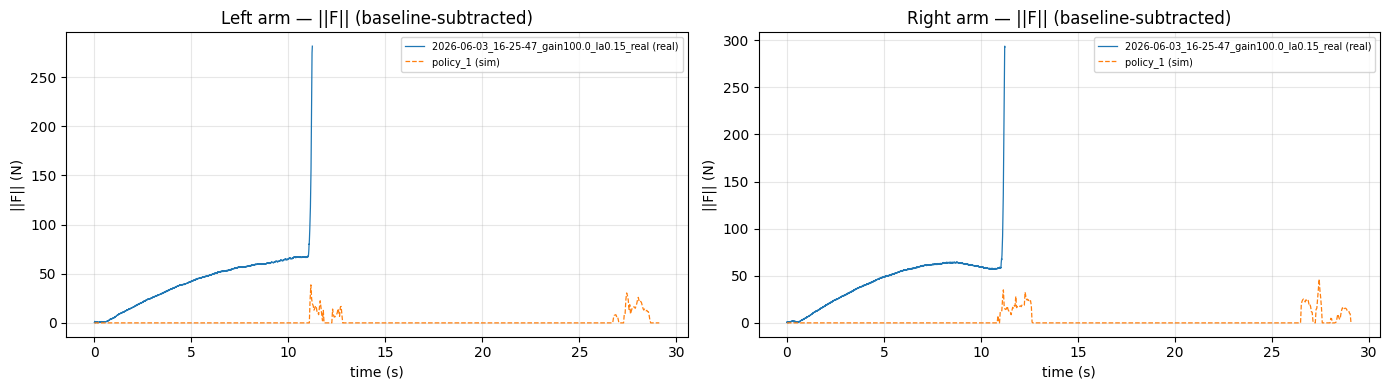

In [8]:
# Pick one npz from each run to compare
real = NPZ
sim_normal = "../logs/rsl_rl/boxlift/2026-06-02_22-26-01/rollout/policy_1.npz"

compare_tcp_force([real, sim_normal], ds=2, subtract_baseline=True)

## All rollouts from a run

In [ ]:
run_dir = run_a  # or run_b
npzs = sorted(run_dir.glob('*real*.npz'))
print(f'{len(npzs)} rollouts found')

compare_tcp_force(npzs, ds=4, subtract_baseline=True)